<a href="https://colab.research.google.com/github/0309Aidana/kazakh-russian-code-swithcing/blob/main/code_switching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Мен кеше домашнее задание орындамадым -> ['KAZ', 'KAZ', 'RUS', 'RUS', 'KAZ'] |переключений: 2
Пока что бұл маған керек емес -> ['RUS', 'RUS', 'KAZ', 'KAZ', 'KAZ', 'KAZ'] |переключений: 1
Мен бүгін сабаққа бармаймын, потому что ауырып тұрмын -> ['KAZ', 'KAZ', 'KAZ', 'KAZ', 'RUS', 'RUS', 'KAZ', 'KAZ'] |переключений: 2
Ертең экзамен бар, а я еще ничего не выучила -> ['KAZ', 'RUS', 'KAZ', 'RUS', 'RUS', 'RUS', 'RUS', 'RUS', 'RUS'] |переключений: 3
Қазір уақыт жоқ, позже жазамын -> ['KAZ', 'KAZ', 'KAZ', 'RUS', 'KAZ'] |переключений: 2
Кешке встретимся, сосын кино көреміз -> ['KAZ', 'RUS', 'KAZ', 'RUS', 'KAZ'] |переключений: 4
Пока что үйде боламын, потом көрісеміз -> ['RUS', 'RUS', 'KAZ', 'KAZ', 'RUS', 'KAZ'] |переключений: 3
Ертең ерте тұруым керек, поэтому долго отырмаймын -> ['KAZ', 'KAZ', 'KAZ', 'KAZ', 'RUS', 'RUS', 'KAZ'] |переключений: 2
Мынау вообще түсініксіз болып тұр -> ['KAZ', 'RUS', 'KAZ', 'KAZ', 'KAZ'] |переключений: 2
Жарайды, онда кейін договоримся -> ['KAZ', 'KAZ', 'KAZ', 'RUS

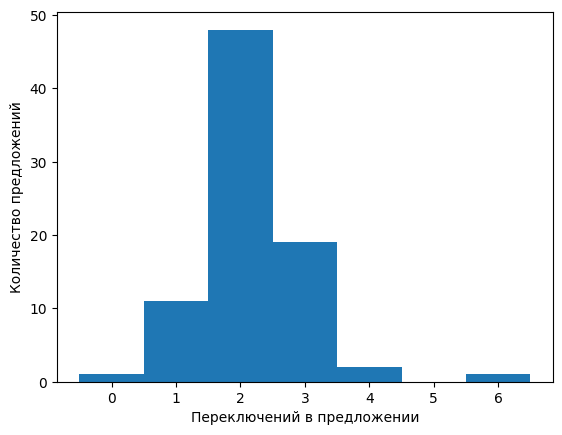

In [46]:
import re
import matplotlib.pyplot as plt
kz_letters=set("әіңғүұқө")
ru_letters=set("эьъфчщц")
mixed_words = {"теманы","каспиге","конспектіні","лекцияны","файлдың","исходгигін","проектіге","презентацияны","пландарды","доставканы","фотоларды","заказды",
               "парольді","темадан","ситуацияны","правиланы","экзаменге","формуданы","презентацияны","материалды","сотрудникпен",}
kazakh_words = {"бар","мен","сен","ол","керек","сәлем","кеше","орындамадым","емес","бармаймын","ауырып","жазамын","кешке","боламын","бе","да","дайындап","етуге",
                "сосын","ерте","отырмаймын","мынау","болып","жарайды","онда","бара","жатырмын","бойынша","былай","ету","жасады","отыр","отыра","алу","неге","осы"
                "жасап","жасау","жатыр","жолда","олармен","оны","тура","айтшы","етпей","жасап","ондай","осы","адам","алдым","ба","болды","екен","есте","жасама","жатып",
                "ма","олар","отырдым","соншама","тастап","шашпашы",}
russian_words = {"и","в","на","не","что","это","хорошо","как","домашнее","задание","пока","экзамен","кино","а","я","еще","ничего","выучила","позже","до","без",
                 "потом","встретимся","утром","потому","вообще","уже","договоримся","долго","поэтому","аккуратно","быстро","вариант","перевод","полный","проект",
                 "завал","замечание","игнор","конца","короче","кофе","настроения","обзор","пробка","прямо","репост","решение","скидка","сразу","глубже","дороботка",
                 "зарплата","проблем","смысле","давление","клиент","намек","негатив","обидно","отзыв","расписание","позитивный","термин","отмена","опыт","уверенно",}
sentences = [
    "Мен кеше домашнее задание орындамадым",
    "Пока что бұл маған керек емес",
    "Мен бүгін сабаққа бармаймын, потому что ауырып тұрмын",
    "Ертең экзамен бар, а я еще ничего не выучила",
    "Қазір уақыт жоқ, позже жазамын",
    "Кешке встретимся, сосын кино көреміз",
    "Пока что үйде боламын, потом көрісеміз",
    "Ертең ерте тұруым керек, поэтому долго отырмаймын",
    "Мынау вообще түсініксіз болып тұр",
    "Жарайды, онда кейін договоримся",
    "Мен уже үйге кетіп бара жатырмын",
    "Сосын бірге дүкенге кіріп шығамыз, хорошо?",
    "Ол маған сразу отвечать етпеді",
    "Мұғалім теманы объяснять етіп берді",
    "Оны быстро закрывть ету керек",
    "Каспиге перевод жасап жібердім",
    "Ол бізге обещание берді",
    "Короче, былай келістік",
    "Жұмыста полный завал болып жатыр",
    "Бұл вариант маған ұнамады",
    "Проект бойынша созвониться етейікші",
    "Файлдарды отгрузить етіп қойдым",
    "Фокус ұстап отыр, отвлекать етпеші",
    "Ол қыз маған игнор ұстады",
    "Мұны сразу репост жасап жібер",
    "Бұған обзор жасап берші",
    "Олармен нормально договориться етіп алдық",
    "Бүгін настроения жоқ",
    "Бастыққа отчет дайындап қойдым",
    "Жолда пробка болып жатыр",
    "Кешке қалай да встречаться етейік",
    "Сабақты до конца тыңдамадым",
    "Бұл тақырыпты потом обсудить етейік",
    "Маған скидка жасап бересіз бе?",
    "Ол маған вообще ұнамайды",
    "Маған прямо сейчас решение керек",
    "Кофе ішіп, чуть-чуть отыра тұрайық",
    "Жұмысты асықпай, аккуратно жасау керек",
    "Бастық маған замечание жасады",
    "Бұл тақырыпты сәл глубже изучать ету керек",
    "Мен конспектіні переписать етіп шықтым",
    "Бүгін лекцияны вообще түсінбедім",
    "Маған файлдың исходнигін жіберші",
    "Осы пректіге сәл дороботка жасау керек",
    "Презентацияны ертең утром дайындап қоямын",
    "Зарплата түскенде сразу перевод жасап жіберемін",
    "Пландарды отменять етуге тура келді",
    "Без проблем, қазір жасап беремін",
    "В смысле, Неге отменить еттің?",
    "Точно білмеймін, бірінші уточнить етіп алу керек",
    "Без разницыб өзің таңда",
    "Доставканы үйге дейін заказать еттік",
    "Фотоларды группаға переслать етуді ұмытпа",
    "Заказды оформить етіп қойдымб ертең келеді",
    "Парольді сбросить етіпб жаңасын қойдым",
    "Білмеймін, мені ешкім предупреждать етпеді",
    "Темадан съехать етпей, тура айтшы",
    "Ондай нәрсеге переживать етудің керегі жоқ",
    "Ситуацияны усложнять етпей-ақ қойщы",
    "Бұл правиланы зубрить етудің керегі жоқ",
    "Экзаменге дайындық қалай болып жатып?",
    "Расписание өзгеріп кетті",
    "Бұл формуланы есте сақтау қиын",
    "Маған намек тастап тастап отырсың ба?",
    "Соншама негатив шашпашы",
    "Презентацияны переделать етуге берді",
    "Бүгін сабақ отмена болды ма?",
    "Сабақта невнимательный болып отырдым",
    "Маған осы материалды распечатать етіп берші",
    "Бұл термин қатты қиын екен",
    "Маған бұлай давление жасама",
    "Бұл сөз маған қатты обидно болды",
    "Маған честно айтшы, не болды?"
    "Ол вообще позитивный адам екен",
    "Клиент бізге отзыв тастап кетті",
    "Бәрін калькулятормен пересчитать етіп алдым",
    "Олар сөздерінде тұрмады",
    "Жаңа сотрудникпен таныстық",
    "Ол өзін қатты уверенно ұстайды екен",
    "Видеоны лайкпен поддержать етіп кетші",
    "Осы проект бізге үлкен опыт берді",
    "Маған осы фильмнің концовкасы ұнамады",
    "Экранның яркостьін сәл түсірші",
]
def label(word):
  if word in mixed_words:
      return "MIX"
  has_kz = any(ch in kz_letters for ch in word)
  has_ru = any(ch in ru_letters for ch in word)
  if has_kz and has_ru:
      return "MIX"
  if has_kz:
      return "KAZ"
  if has_ru:
      return "RUS"
  if word in kazakh_words:
      return "KAZ"
  if word in russian_words:
      return "RUS"
  return "?"
switch_counts = []
for s in sentences:
  words = re.findall (r"\w+", s.lower())
  labels = [label(w)for w in words]
  known = [l for l in labels if l !="?"]
  switches = 0
  for i in range (len(known)-1):
    if known[i] != known[i+1]:
      switches = switches + 1
  switch_counts.append(switches)
  print(s,"->",labels,"|переключений:",switches)
plt.hist(switch_counts, bins=range(0,max(switch_counts)+2),align="left")
plt.xlabel("Переключений в предложении")
plt.ylabel("Количество предложений")
unknown = set()
for s in sentences:
  for w in re.findall(r"\w+",s.lower()):
    if label(w) == "?":
      unknown.add(w)
print(sorted(unknown))
from collections import Counter
all_labels = []
for s in sentences:
  for w in re.findall(r"\w+", s.lower()):
    all_labels.append(label(w))
print(Counter(all_labels))


In [47]:
test_sentences=[
    "Оның сөздері маған мотивация берді",
    "Заказды отслеживать етіп отырмын",
    "Чатты случайно өшіріп алдым",
    "Бәрін біртіндеп сортировка жасау керек",
    "Осы детальге акцент жасау керек",
    "Ол мені жестко подвести етті",
    "Бұны сразу сливать етпей, поддерживать ету керек",
    "Соншама паника жасамай, спокойно решать етейік",
    "Зарядка бар ма?",
    "Маған бұл тема интересный емес",
    "Мынаны ертеңге дейін жасап бітіруім керек, иначе үлгермей қаламын",
    "Қойшы, мен просто шаршап тұрмын",
    "Бүгін ауа райы жақсы екен, прогулкаға шығайық",
    "Когда он спросил про это, сен не деп едің?",
    "Аа, түсіндім, онда проблема жоқ",
    "Сен маған потом скинб эти фотки",
    "Қойшы, оған мән берме, все нормально",
    "Осы жерде күте тұршы, мен магазинге кіріп шығайын",
    "Бірдеңе жеп алайықшы, я голодная",
    "На данный момент, біз білім алу керекпіз"
]

In [48]:
from collections import Counter
test_labels = []
for s in test_sentences:
  words = re.findall(r"\w+", s.lower ())
  labels = [label(w)for w in words]
  test_labels.extend(labels)
  print(s, "->", labels)
print(Counter(test_labels))
print("Total words:", len(test_labels))
print(sum(switch_counts))
len(switch_counts)
all_labels= []
for s in sentences:
  for w in re.findall(r"\w+", s.lower()):
    all_labels.append(label(w))
print(Counter(all_labels))

Оның сөздері маған мотивация берді -> ['KAZ', 'KAZ', 'KAZ', 'RUS', 'KAZ']
Заказды отслеживать етіп отырмын -> ['MIX', 'RUS', 'KAZ', '?']
Чатты случайно өшіріп алдым -> ['RUS', 'RUS', 'KAZ', 'KAZ']
Бәрін біртіндеп сортировка жасау керек -> ['KAZ', 'KAZ', '?', 'KAZ', 'KAZ']
Осы детальге акцент жасау керек -> ['KAZ', 'RUS', 'RUS', 'KAZ', 'KAZ']
Ол мені жестко подвести етті -> ['KAZ', 'KAZ', '?', '?', 'KAZ']
Бұны сразу сливать етпей, поддерживать ету керек -> ['KAZ', 'RUS', 'RUS', 'KAZ', 'RUS', 'KAZ', 'KAZ']
Соншама паника жасамай, спокойно решать етейік -> ['KAZ', '?', '?', '?', 'RUS', 'KAZ']
Зарядка бар ма? -> ['?', 'KAZ', 'KAZ']
Маған бұл тема интересный емес -> ['KAZ', 'KAZ', '?', '?', 'KAZ']
Мынаны ертеңге дейін жасап бітіруім керек, иначе үлгермей қаламын -> ['?', 'KAZ', 'KAZ', 'KAZ', 'KAZ', 'KAZ', 'RUS', 'KAZ', 'KAZ']
Қойшы, мен просто шаршап тұрмын -> ['KAZ', 'KAZ', '?', '?', 'KAZ']
Бүгін ауа райы жақсы екен, прогулкаға шығайық -> ['KAZ', '?', '?', 'KAZ', 'KAZ', 'KAZ', 'KAZ']
Когда